# Exact bayesian lineal Regression

## Regresión Bayesiana con Aproximación Tipo II de Máxima Verosimilitud


**Objetivo**: Ajustar un modelo de regresión bayesiano con estimación de hiperparámetros $(\alpha)$ (precisión de los pesos) y $(\beta)$ (precisión del ruido).


1. Generación de Datos

 **Modelo verdadero**:
$[ y(x) = \sin(2\pi x) ]$

 **Observaciones**:
$[ t = y(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \beta^{-1}) ]$



In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10**4)  # Reproducibilidad
N_tot = 100            # Total de puntos
sigma2 = 0.01          # Varianza del ruido
beta = 1/sigma2
x_tot = np.linspace(0, 1, N_tot)
y_tot = np.sin(2*np.pi*x_tot)
t_tot = y_tot + np.sqrt(1/beta)*np.random.randn(N_tot)


2. División Train/Test

 **Entrenamiento**: 10 puntos (10% de los datos).

  **Test**: 90 puntos restantes.


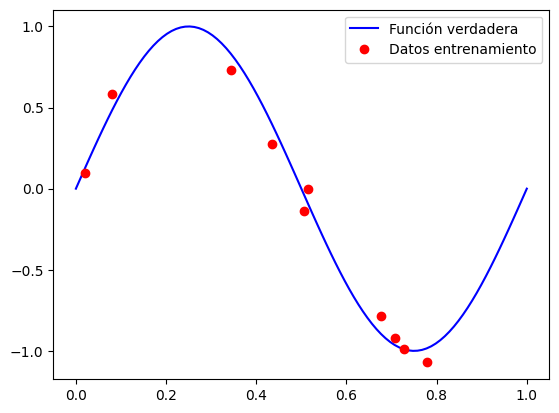

In [2]:
N = 10
index = np.random.permutation(N_tot)
x, t = x_tot[index[:N]], t_tot[index[:N]]
x_test, t_test = x_tot[index[N:]], t_tot[index[N:]]

fig, ax = plt.subplots()
ax.plot(x_tot, y_tot, 'b', label='Función verdadera')
ax.plot(x, t, '.r', markersize=12, label='Datos entrenamiento')
ax.legend()
plt.show()

3. Funciones de Base Radial (RBF)

 **Matriz de diseño**:
$[\Phi(x) = [1, \exp\left(-\frac{(x-\mu_1)^2}{2s^2}\right), \dots, \exp(-\frac{(x-\mu_{M-1})^2}{2s^2})]
]$

* \(M=10\) bases, \(\mu_j\) espaciados uniformemente.

* $(s^2 = 0.05 \cdot \Delta\mu)$ (ancho de las bases).


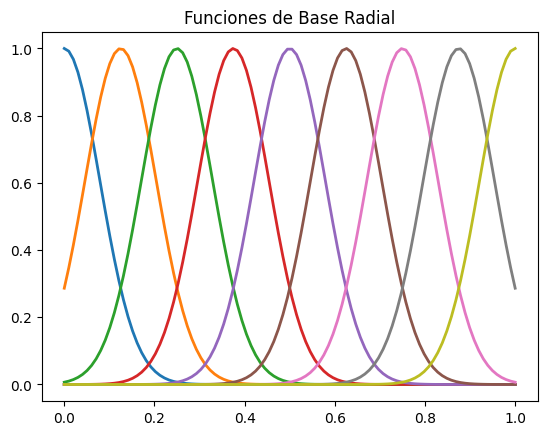

In [3]:
M = 10
mu = np.linspace(0, 1, M-1)
s2 = 0.05*(mu[1] - mu[0])

PHI_tot = np.ones((N_tot, M))
for i in range(1, M):
    PHI_tot[:, i] = np.exp(-(x_tot - mu[i-1])**2/(2*s2))

fig, ax = plt.subplots()
ax.plot(x_tot, PHI_tot[:, 1:], linewidth=2)
plt.title('Funciones de Base Radial')
plt.show()

4. Estimación de Hiperparámetros $((\alpha), (\beta))$

**Aproximación Tipo II (Evidence Approximation)**:

1. **Posterior de los pesos**:
$[ p(\mathbf{w}|\mathbf{t}, \alpha, \beta) = \mathcal{N}(\mathbf{m}_N, \mathbf{S}_N)
]$

2. **Actualización de $(\alpha)$ y $(\beta)$**:
$[
 \alpha = \frac{\gamma}{\mathbf{m}_N^T\mathbf{m}_N}, \quad \beta^{-1} = \frac{\|\mathbf{t}-\Phi\mathbf{m}_N\|^2}{N-\gamma}
]$
 donde $(\gamma = \sum_i \frac{\lambda_i}{\lambda_i + \alpha})$ (parámetros efectivos).


In [4]:
PHI = np.ones((N, M))
for i in range(1, M):
    PHI[:, i] = np.exp(-(x - mu[i-1])**2/(2*s2))

# Inicialización
alpha, betae = 1e-1, 1e-1
niters = 100
rho, V = np.linalg.eig(PHI.T @ PHI)
lamb = betae * rho

# Almacenamiento de valores
betav = np.zeros(niters)
alphav = np.zeros(niters)

# Iteración EM
for n in range(niters):
    A = alpha*np.eye(M) + betae*(PHI.T @ PHI)
    Ainv = np.linalg.solve(A, np.eye(M))
    mN = betae * Ainv @ PHI.T @ t[:, np.newaxis]

    gamma = np.sum(lamb / (lamb + alpha))
    alpha = gamma / (mN.T @ mN).item()

    resid = t[:, np.newaxis] - PHI @ mN
    betaeInv = (resid.T @ resid).item() / (N - gamma)
    betae = 1 / betaeInv
    lamb = betae * rho

    alphav[n] = alpha
    betav[n] = betae


5. Distribución Predictiva
**Media y varianza predictiva**:
$[
 \mathbb{E}[t^*|x^*] = \Phi(x^*)\mathbf{m}_N
]$
$[
 \text{Var}[t^*|x^*] = \beta^{-1} + \Phi(x^*)\mathbf{S}_N\Phi(x^*)^T
]$


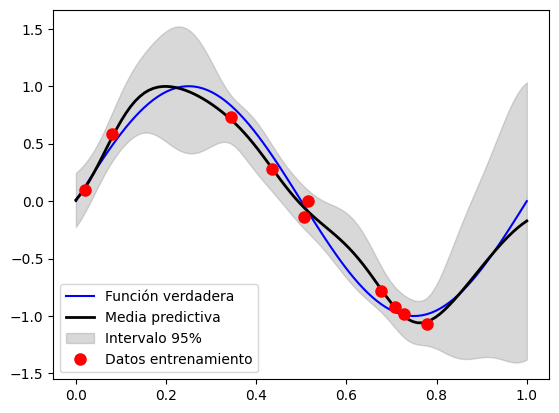

In [5]:
SNInv = alpha*np.eye(M) + betae*(PHI.T @ PHI)
SN = np.linalg.solve(SNInv, np.eye(M))
mN = betae * SN @ PHI.T @ t[:, np.newaxis]

mpred = PHI_tot @ mN
vpred = 1/betae + np.diag(PHI_tot @ SN @ PHI_tot.T)

fig, ax = plt.subplots()
ax.plot(x_tot, y_tot, 'b', label='Función verdadera')
ax.plot(x_tot, mpred, 'k', linewidth=2, label='Media predictiva')
ax.fill_between(x_tot,
                mpred.flatten() - 2*np.sqrt(vpred),
                mpred.flatten() + 2*np.sqrt(vpred),
                color='gray', alpha=0.3, label='Intervalo 95%')
ax.plot(x, t, 'or', markersize=8, label='Datos entrenamiento')
ax.legend()
plt.show()

# Prior y posterior

Regresión Bayesiana Lineal: Actualización de Conocimiento
**Objetivo**: Demostrar cómo el conocimiento sobre los parámetros $(w_0)$ y $(w_1)$ se actualiza bayesianamente con datos observados.


## 1. Generación de Datos Sintéticos

**Modelo verdadero**:
$[
 y(x) = w_0 + w_1 x, \quad w_0 = -0.3,\, w_1 = 0.5
]$

 **Ruido observado**:
$[
 t = y(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \beta^{-1}),\, \beta = 100
]$


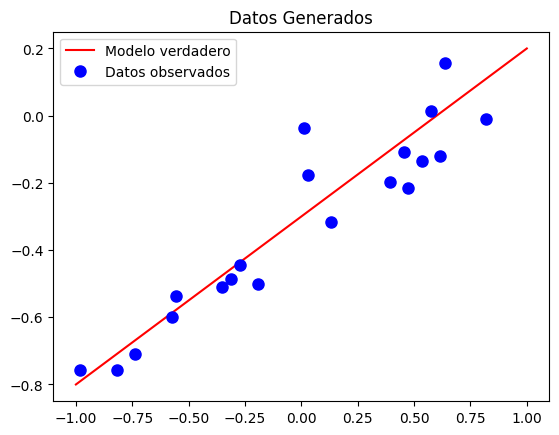

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Configuración
np.random.seed(10**3)
w0_true, w1_true = -0.3, 0.5
beta_inv = 0.01
N_tot = 100

# Generar datos
x_tot = np.linspace(-1, 1, N_tot)
true_y = w0_true + w1_true*x_tot
noisy_y = true_y + np.sqrt(beta_inv)*np.random.randn(N_tot)

# Seleccionar subconjunto
N = 20
index = np.random.permutation(N_tot)
x, t = x_tot[index[:N]], noisy_y[index[:N]]

# Visualización
fig, ax = plt.subplots()
ax.plot(x_tot, true_y, 'r', label='Modelo verdadero')
ax.plot(x, t, 'ob', markersize=8, label='Datos observados')
ax.set_title('Datos Generados')
ax.legend()
plt.show()

## 2. Distribución a Priori de los Parámetros
 **Especificación del prior**:
$[
 \mathbf{w} = \begin{bmatrix} w_0 \\ w_1 \end{bmatrix} \sim \mathcal{N}(\mathbf{0}, \alpha\mathbf{I}),\, \alpha = 2
]$

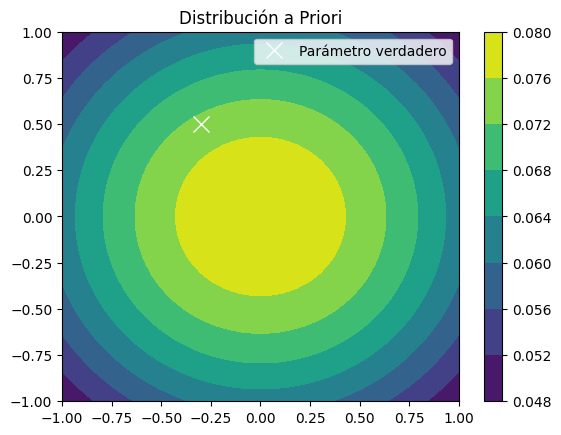

In [7]:
# Configurar grid para visualización
Nt = 50
w0_grid = np.linspace(-1, 1, Nt)
w1_grid = np.linspace(-1, 1, Nt)
W0, W1 = np.meshgrid(w0_grid, w1_grid)

# Función para plotear distribuciones
def plot_gaussian(mean, cov, w0t, w1t, title):
    pos = np.column_stack((W0.flatten(), W1.flatten()))
    pdf = multivariate_normal.pdf(pos, mean=mean, cov=cov)
    plt.contourf(W0, W1, pdf.reshape(Nt, Nt))
    plt.colorbar()
    plt.plot(w0t, w1t, 'wx', markersize=12, label='Parámetro verdadero')
    plt.title(title)
    plt.legend()
    plt.show()

# Prior inicial
mean_prior = np.zeros(2)
cov_prior = 2*np.eye(2)
plot_gaussian(mean_prior, cov_prior, w0_true, w1_true, 'Distribución a Priori')

## 3. Muestreo de Líneas del Prior
 **Muestreo de parámetros**:
$[ \mathbf{w}^{(i)} \sim \mathcal{N}(\mathbf{0}, \alpha\mathbf{I})
]$

 **Líneas correspondientes**:
$[
 y^{(i)}(x) = w_0^{(i)} + w_1^{(i)}x
]$

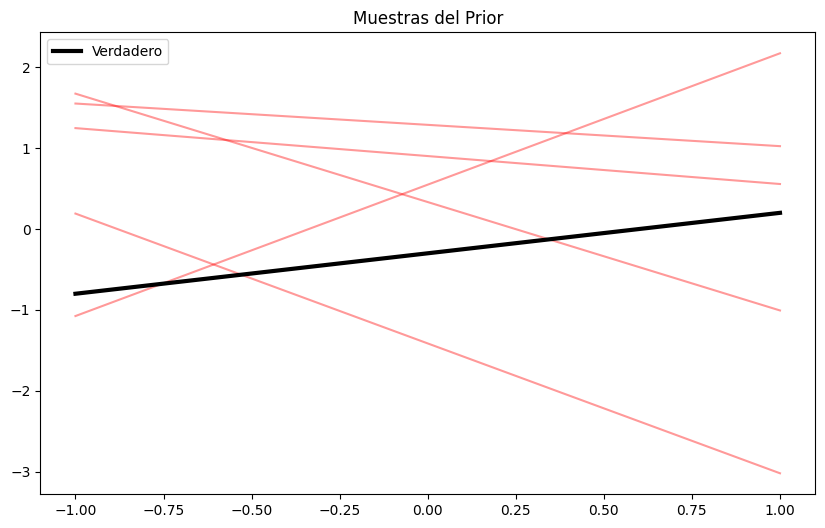

In [8]:

def plot_lines(mean, cov, nsamples, title):
    samples = multivariate_normal.rvs(mean, cov, nsamples)
    plt.figure(figsize=(10, 6))
    for w0, w1 in samples:
        plt.plot(x_tot, w0 + w1*x_tot, 'r', alpha=0.4)
    plt.plot(x_tot, true_y, 'k', linewidth=3, label='Verdadero')
    plt.title(title)
    plt.legend()
    plt.show()

plot_lines(mean_prior, cov_prior, 5, 'Muestras del Prior')

## 4. Actualización Posterior con Datos
**Teorema de Bayes**:
$[
 p(\mathbf{w}|\mathbf{t}) \propto p(\mathbf{t}|\mathbf{w})p(\mathbf{w})
]$

 **Posterior**:
$[
 \mathbf{w}|\mathbf{t} \sim \mathcal{N}(\mathbf{m}_N, \mathbf{S}_N)
 ]$
donde:
$[
 \mathbf{S}_N^{-1} = \alpha\mathbf{I} + \beta\Phi^T\Phi
]$

$[
 \mathbf{m}_N = \beta\mathbf{S}_N\Phi^T\mathbf{t}
]$



### 4.1 Después de 1 Observación

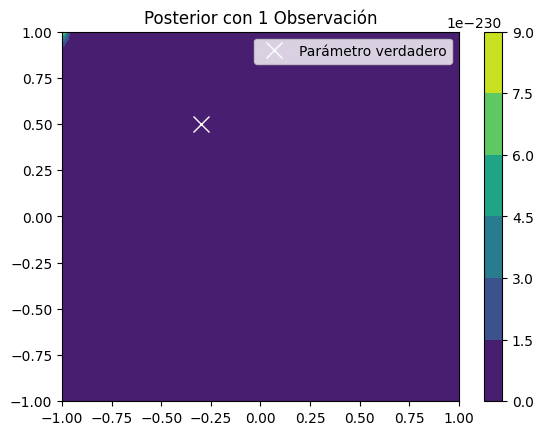

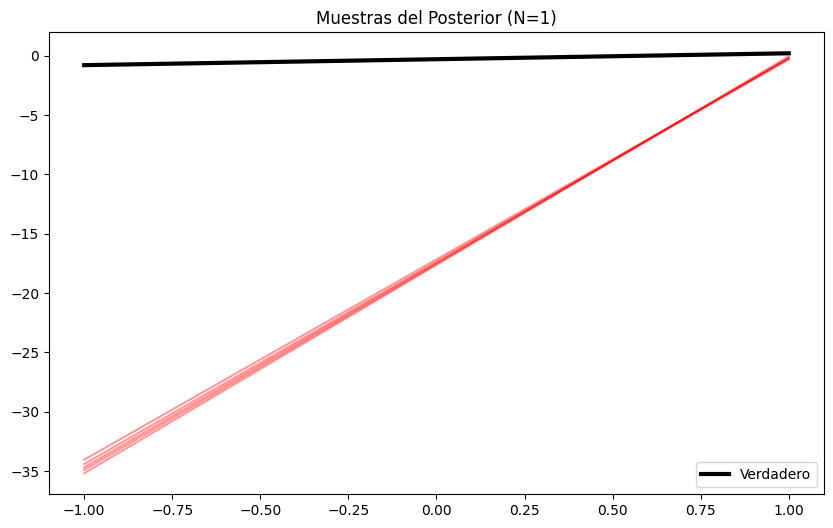

In [9]:
# Primera observación
phi1 = np.array([1, x[15]])
S_inv = 2*np.eye(2) + 100*phi1.T@phi1
S = np.linalg.inv(S_inv)
mN = 100*S@phi1.T*t[15]

plot_gaussian(mN, S, w0_true, w1_true, 'Posterior con 1 Observación')
plot_lines(mN, S, 5, 'Muestras del Posterior (N=1)')

### 4.2 Después de 2 Observaciones

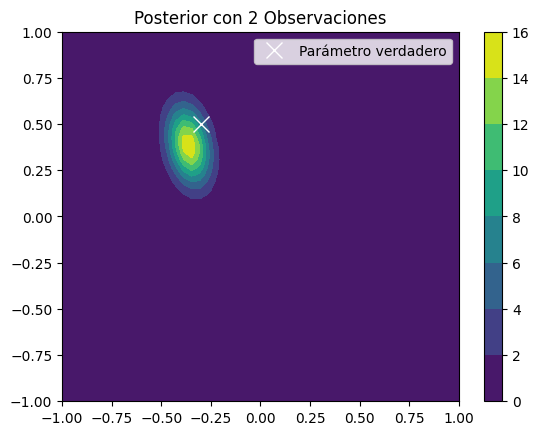

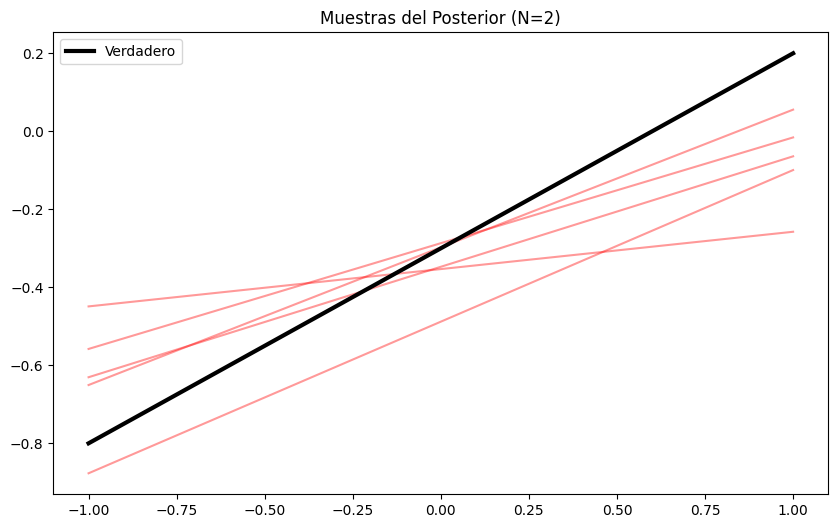

In [10]:
# Segunda observación
phi2 = np.array([[1, x[15]], [1, x[10]]])
t2 = np.array([t[15], t[10]])

S_inv = 2*np.eye(2) + 100*phi2.T@phi2
S = np.linalg.inv(S_inv)
mN = 100*S@phi2.T@t2

plot_gaussian(mN, S, w0_true, w1_true, 'Posterior con 2 Observaciones')
plot_lines(mN, S, 5, 'Muestras del Posterior (N=2)')

### 4.3 Después de 5 Observaciones

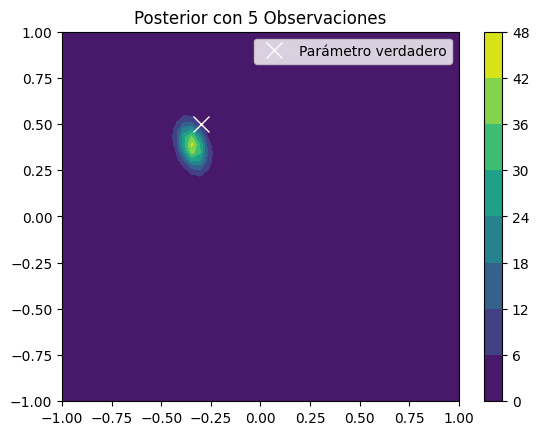

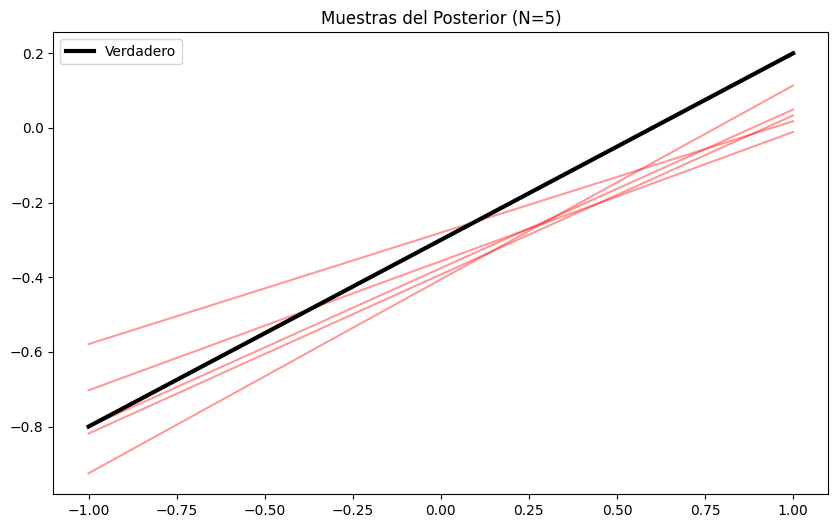

In [11]:
# Cinco observaciones
phi5 = np.array([[1, x[i]] for i in [15, 10, 5, 0, 8]])
t5 = np.array([t[i] for i in [15, 10, 5, 0, 8]])

S_inv = 2*np.eye(2) + 100*phi5.T@phi5
S = np.linalg.inv(S_inv)
mN = 100*S@phi5.T@t5

plot_gaussian(mN, S, w0_true, w1_true, 'Posterior con 5 Observaciones')
plot_lines(mN, S, 5, 'Muestras del Posterior (N=5)')

## 5. Conclusiones

 1. **Convergencia al verdadero**: La distribución posterior se concentra alrededor de los parámetros verdaderos $(w_0=-0.3, w_1=0.5) conforme aumenta $(N)$.
 2. **Reducción de incertidumbre**: La covarianza posterior disminuye con más datos.
 3. **Muestras representativas**: Las líneas muestreadas del posterior se alinean con los datos observados.

# Regresión Bayesiana con Funciones de Base Radial

**Objetivo**: Implementar regresión bayesiana con funciones de base radial (RBF) para modelar datos no lineales, incluyendo estimación de incertidumbre.


## 1. Generación de Datos Sintéticos
 **Modelo verdadero**:
$ [ y(x) = \sin(2\pi x) ]$

 **Ruido observado**:
$ [ t = y(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \beta^{-1}),\, \beta = 100 ]$


In [12]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10**4)  # Reproducibilidad
N_tot = 100
sigma2 = 0.01          # Varianza del ruido
beta = 1/sigma2
x_tot = np.linspace(0, 1, N_tot)
y_tot = np.sin(2*np.pi*x_tot)
t_tot = y_tot + np.sqrt(1/beta)*np.random.randn(N_tot)

## 2. División de Datos (Train/Test)
- **Entrenamiento**: 10 puntos (10% de los datos).

- **Test**: 90 puntos restantes (no usados en este ejemplo).

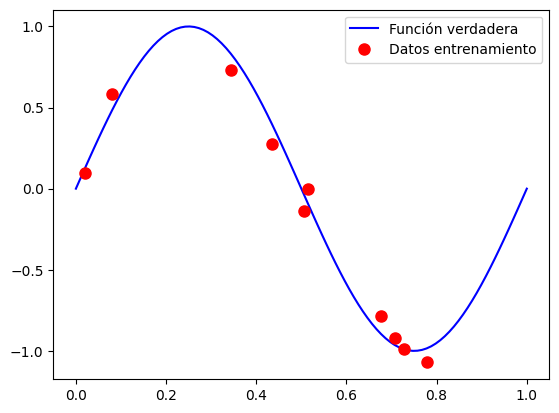

In [15]:
N = 10
index = np.random.permutation(N_tot)
x_train, t_train = x_tot[index[:N]], t_tot[index[:N]]
x_test, t_test = x_tot[index[N:]], t_tot[index[N:]]

# Visualización
fig, ax = plt.subplots()
ax.plot(x_tot, y_tot, 'b', label='Función verdadera')
ax.plot(x_train, t_train, 'or', markersize=8, label='Datos entrenamiento')
ax.legend()
plt.show()

## 3. Diseño de Funciones de Base Radial (RBF)

**Matriz de diseño**:
$[
 \Phi(x) = \left[1, \exp\left(-\frac{(x-\mu_1)^2}{2s^2}\right), \dots, \exp\left(-\frac{(x-\mu_{M-1})^2}{2s^2}\right)\right]
]$
* $(M=10)$ bases (incluyendo bias).
* $(\mu_j)$: Centros espaciados uniformemente en [0, 1].
* $(s^2 = 0.05 \cdot \Delta\mu)$: Ancho controlado por espaciado entre centros.

In [16]:
M = 10
mu = np.linspace(0, 1, M-1)  # Centros de las RBF
s2 = 0.05*(mu[1] - mu[0])    # Ancho de las bases

# Matriz de diseño para todos los puntos
PHI_tot = np.ones((N_tot, M))
for i in range(1, M):
    PHI_tot[:, i] = np.exp(-(x_tot - mu[i-1])**2/(2*s2))

## 4. Inferencia Bayesiana
**Distribución posterior de los pesos**:
$[
 p(\mathbf{w}|\mathbf{t}) = \mathcal{N}(\mathbf{m}_N, \mathbf{S}_N)
]$
 donde:
$ [
 \mathbf{S}_N^{-1} = \alpha\mathbf{I} + \beta\Phi^T\Phi
]$
$[
 \mathbf{m}_N = \beta\mathbf{S}_N\Phi^T\mathbf{t}
]$

In [17]:
# Matriz de diseño para entrenamiento
PHI_train = np.ones((N, M))
for i in range(1, M):
    PHI_train[:, i] = np.exp(-(x_train - mu[i-1])**2/(2*s2))

# Hiperparámetros
alpha = 1  # Precisión a priori de los pesos

# Cálculo de parámetros posteriores
SNInv = alpha*np.eye(M) + beta*(PHI_train.T @ PHI_train)
SN = np.linalg.solve(SNInv, np.eye(M))
mN = beta * SN @ PHI_train.T @ t_train[:, np.newaxis]

## 5. Distribución Predictiva
**Media y varianza predictiva**:
$[
 \mathbb{E}[t^*|x^*] = \Phi(x^*)\mathbf{m}_N
]$
$[
 \text{Var}[t^*|x^*] = \beta^{-1} + \Phi(x^*)\mathbf{S}_N\Phi(x^*)^T
]$

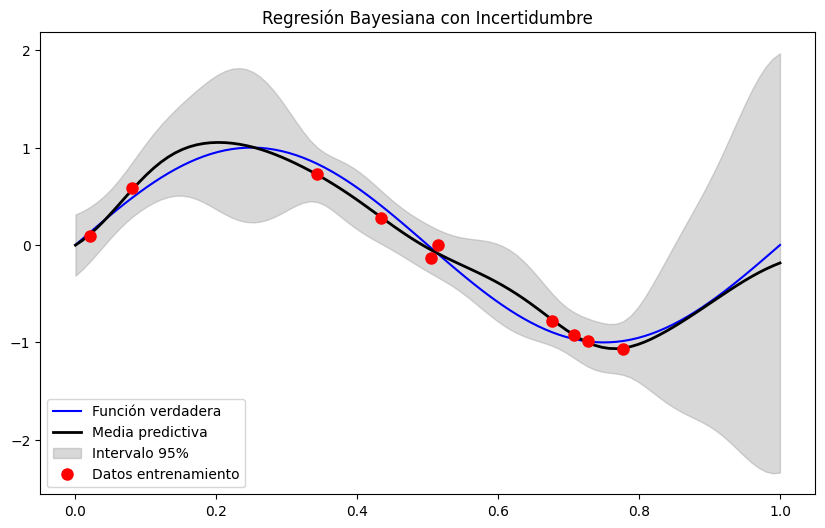

In [18]:
# Predicción
y_pred = PHI_tot @ mN
pred_var = 1/beta + np.diag(PHI_tot @ SN @ PHI_tot.T)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_tot, y_tot, 'b', label='Función verdadera')
ax.plot(x_tot, y_pred, 'k', linewidth=2, label='Media predictiva')
ax.fill_between(x_tot,
                y_pred.flatten() - 2*np.sqrt(pred_var),
                y_pred.flatten() + 2*np.sqrt(pred_var),
                color='gray', alpha=0.3, label='Intervalo 95%')
ax.plot(x_train, t_train, 'or', markersize=8, label='Datos entrenamiento')
ax.set_title('Regresión Bayesiana con Incertidumbre')
ax.legend()
plt.show()

## 6. Interpretación de Resultados
1. **Incertidumbre creciente en regiones sin datos**: Las bandas grises se ensanchan donde no hay puntos de entrenamiento.
2. **Suavizado óptimo**: La media predictiva sigue la tendencia general sin sobreajustar el ruido.
3. **Efecto del prior**: La elección de $(\alpha=1)$ controla la magnitud de los pesos, previniendo sobreajuste.


## 7. Posibles Mejoras
- **Optimización de hiperparámetros**: Usar Evidence Approximation para aprender $(\alpha)$ y $(\beta)$.
- **Selección de bases**: Experimentar con $(M)$ y $(s^2)$ para mejorar el ajuste.
- **Validación en test**: Calcular métricas como el MSE en datos no vistos.

# Usando SciKit Learn

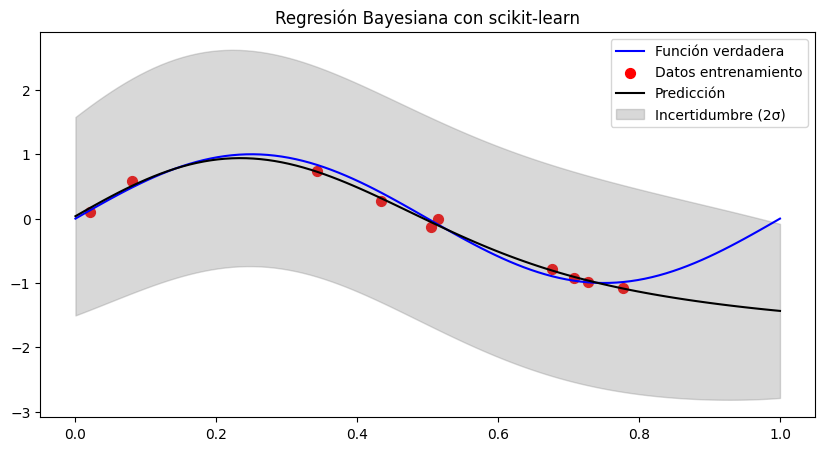

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import BayesianRidge

# Generación de datos
np.random.seed(10**4)  # Reproducibilidad
N_tot = 100
sigma2 = 0.01          # Varianza del ruido
beta = 1/sigma2
x_tot = np.linspace(0, 1, N_tot)
y_tot = np.sin(2*np.pi*x_tot)
t_tot = y_tot + np.sqrt(1/beta)*np.random.randn(N_tot)

# Selección de datos de entrenamiento
N = 10
index = np.random.permutation(N_tot)
x_train, t_train = x_tot[index[:N]], t_tot[index[:N]]
x_test, t_test = x_tot[index[N:]], t_tot[index[N:]]


# Crear características polinómicas + RBF
def rbf_features(x, centers, gamma=10):
    return np.exp(-gamma * (x[:, None] - centers)**2)

centers = np.linspace(0, 1, 9)  # 8 centros RBF + intercept
X_train = rbf_features(x_train, centers)
X_tot = rbf_features(x_tot, centers)

# Modelo Bayesiano
model = BayesianRidge(compute_score=True)
model.fit(X_train, t_train)

# Predicción con incertidumbre
y_pred, y_std = model.predict(X_tot, return_std=True)

# Visualización
plt.figure(figsize=(10, 5))
plt.plot(x_tot, y_tot, 'b', label='Función verdadera')
plt.scatter(x_train, t_train, s=50, c='red', label='Datos entrenamiento')
plt.plot(x_tot, y_pred, 'k', label='Predicción')
plt.fill_between(x_tot, y_pred - 2*y_std, y_pred + 2*y_std,
                 alpha=0.3, color='gray', label='Incertidumbre (2σ)')
plt.title('Regresión Bayesiana con scikit-learn')
plt.legend()
plt.show()